# 02 — IC / ICIR Analysis

**Purpose**: Visualise the feature information coefficient (IC) and IC Information Ratio (ICIR) across all three return horizons, and examine factor decay.

Prerequisite: run `scripts/factor_research.py` first to generate `reports/factor_research_{1y,3y,5y}.csv`.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

horizons = ['1y', '3y', '5y']
reports = {h: ROOT / 'reports' / f'factor_research_{h}.csv' for h in horizons}
dfs = {}
for h, path in reports.items():
    if path.exists():
        dfs[h] = pd.read_csv(path)
        print(f'{h}: {len(dfs[h])} features loaded from {path.name}')
    else:
        print(f'MISSING: {path} — run scripts/factor_research.py')

1y: 207 features loaded from factor_research_1y.csv
3y: 206 features loaded from factor_research_3y.csv
5y: 204 features loaded from factor_research_5y.csv


## 1 — Top features by |ICIR| (all horizons)

In [2]:
for h, df in dfs.items():
    if 'icir' not in df.columns:
        continue
    top = df.sort_values('icir', key=abs, ascending=False).head(20)
    print(f'\n--- {h} horizon: top 20 by |ICIR| ---')
    print(top[['feature', 'mean_ic', 'std_ic', 'icir', 'n_years', 'pct_positive_ic']].to_string(index=False))


--- 1y horizon: top 20 by |ICIR| ---
              feature  mean_ic  std_ic    icir  n_years  pct_positive_ic
           ev_revenue -0.16042 0.08321 -1.9280       17            0.000
             ps_ratio -0.16020 0.09413 -1.7018       17            0.000
       sales_to_price  0.16018 0.09414  1.7015       17            1.000
       altman_z_score  0.09966 0.05953  1.6740       17            0.941
                  fcf  0.15306 0.09428  1.6234        5            0.800
 quality_in_recession  0.18070 0.11457  1.5772        3            1.000
   value_in_recession  0.18609 0.12068  1.5420        3            1.000
            recession  0.19123 0.12827  1.4909        3            1.000
      value_composite  0.18888 0.12698  1.4874       17            0.941
  ps_ratio_sector_pct -0.14690 0.10267 -1.4308       17            0.118
   value_in_high_rate  0.13787 0.09849  1.3999        6            1.000
net_income_growth_yoy  0.06836 0.04905  1.3938       16            0.875
        ocf_t

## 2 — ICIR bar chart (top 30 per horizon)

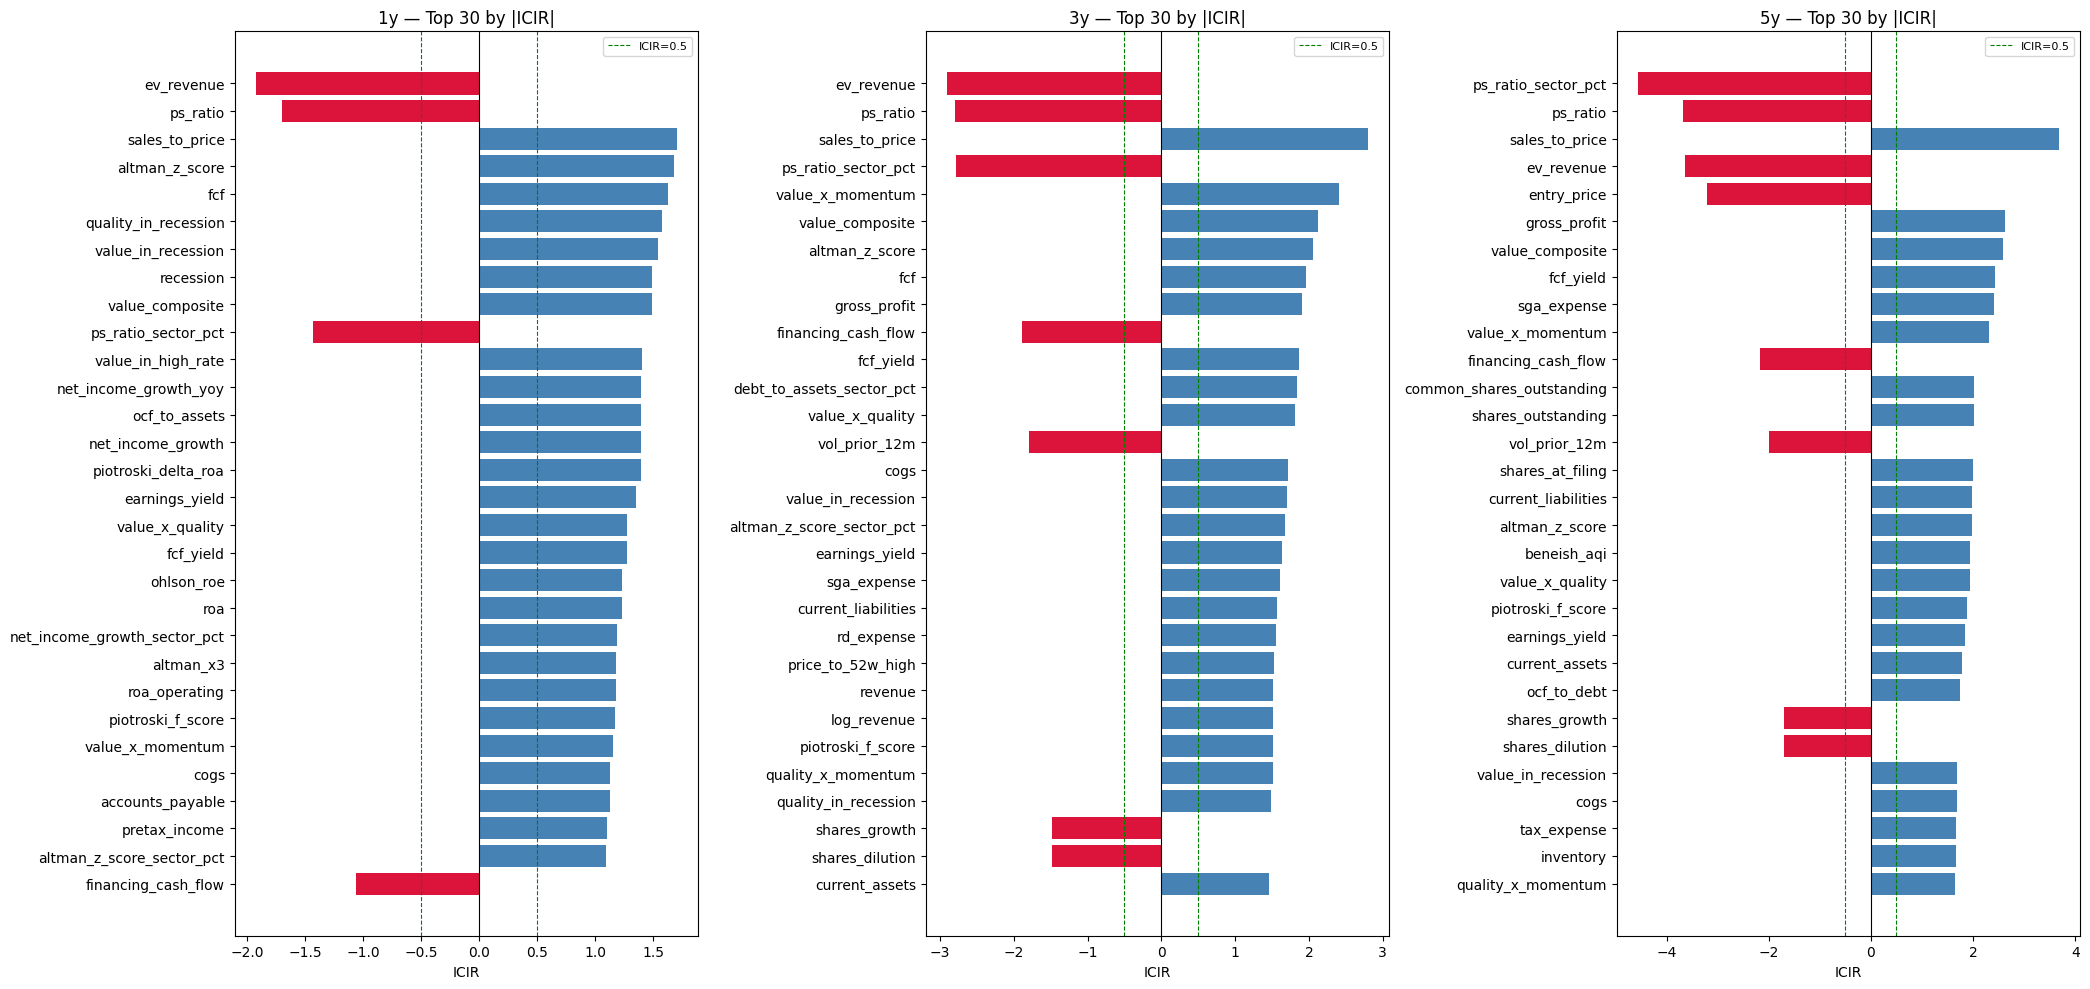

In [3]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 10))
if len(dfs) == 1:
    axes = [axes]

for ax, (h, df) in zip(axes, dfs.items()):
    if 'icir' not in df.columns:
        continue
    top = df.sort_values('icir', key=abs, ascending=False).head(30)
    colors = ['steelblue' if v > 0 else 'crimson' for v in top['icir']]
    ax.barh(top['feature'][::-1], top['icir'][::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(0.5, color='green', linestyle='--', linewidth=0.8, label='ICIR=0.5')
    ax.axvline(-0.5, color='green', linestyle='--', linewidth=0.8)
    ax.set_title(f'{h} — Top 30 by |ICIR|')
    ax.set_xlabel('ICIR')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3 — IC stability (pct_positive_ic) vs mean_ic scatter

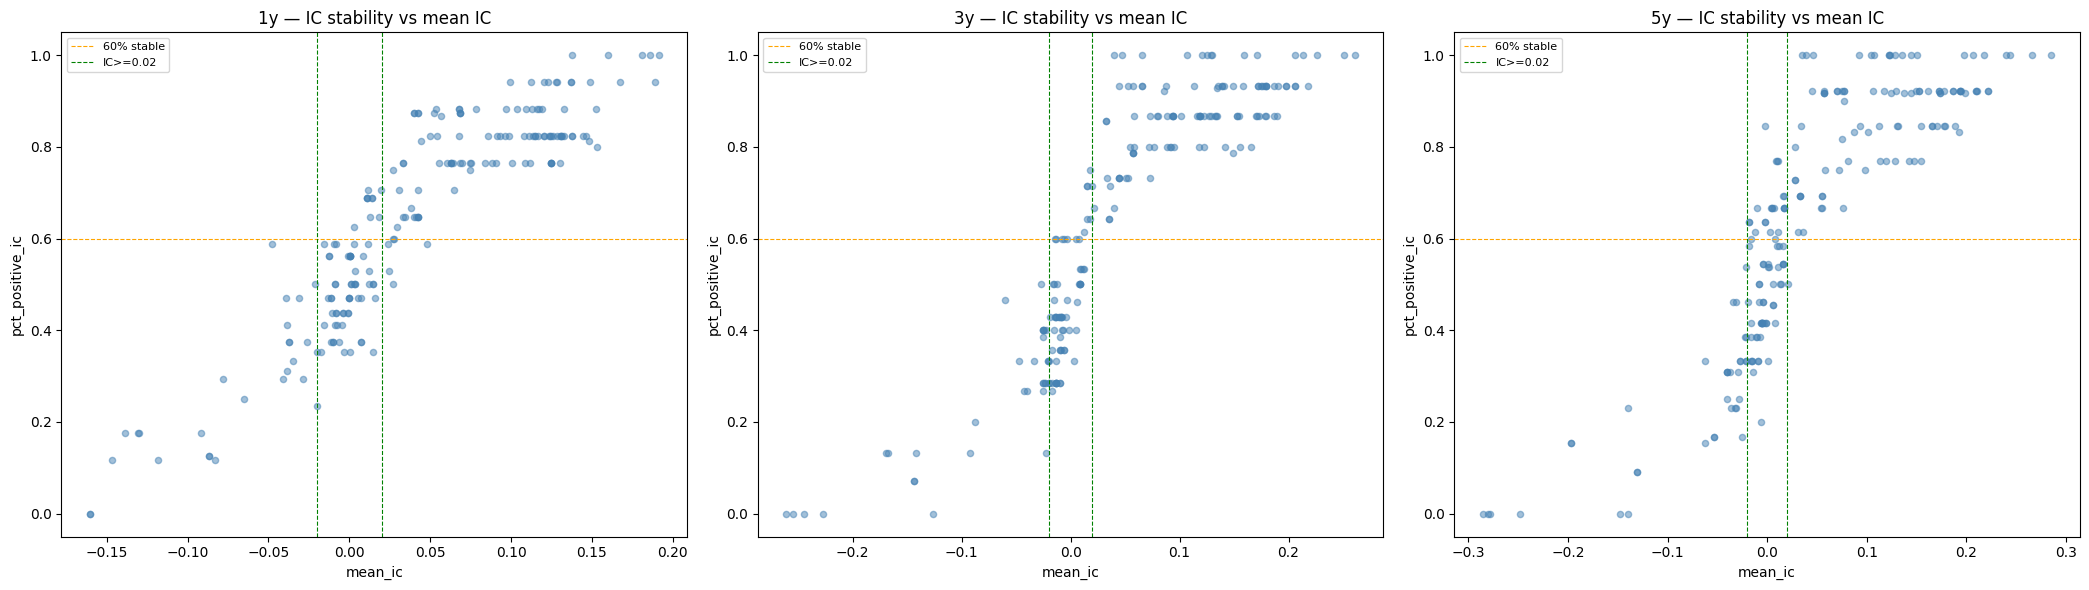

In [4]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 6))
if len(dfs) == 1:
    axes = [axes]

for ax, (h, df) in zip(axes, dfs.items()):
    if 'mean_ic' not in df.columns or 'pct_positive_ic' not in df.columns:
        continue
    ax.scatter(df['mean_ic'], df['pct_positive_ic'], alpha=0.5, s=20, color='steelblue')
    ax.axhline(0.60, linestyle='--', color='orange', linewidth=0.8, label='60% stable')
    ax.axvline(0.02, linestyle='--', color='green', linewidth=0.8, label='IC>=0.02')
    ax.axvline(-0.02, linestyle='--', color='green', linewidth=0.8)
    ax.set_title(f'{h} — IC stability vs mean IC')
    ax.set_xlabel('mean_ic')
    ax.set_ylabel('pct_positive_ic')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Feature overlap across horizons

In [5]:
import json

feat_sets = {}
for h in horizons:
    p = ROOT / 'models' / f'feature_sets_{h}.json'
    if p.exists():
        with open(p) as f:
            feat_sets[h] = set(json.load(f)['features'])
        print(f'{h}: {len(feat_sets[h])} selected features')

if len(feat_sets) == 3:
    shared_all = feat_sets['1y'] & feat_sets['3y'] & feat_sets['5y']
    print(f'\nFeatures in ALL three horizons: {len(shared_all)}')
    for f in sorted(shared_all):
        print(f'  {f}')

1y: 45 selected features
3y: 45 selected features
5y: 42 selected features

Features in ALL three horizons: 22
  altman_x4
  book_to_market
  debt_to_assets_sector_pct
  earnings_yield
  fcf_yield
  financing_cashflow_to_assets
  gross_profit_to_assets
  ocf_to_assets
  operating_margin_sector_pct
  pb_ratio_sector_pct
  piotroski_f_score_9
  piotroski_ocf_pos
  piotroski_roa_pos
  piotroski_shares_ok
  ps_ratio_sector_pct
  quality_x_momentum
  quarterly_positive_rev_frac
  roa_sector_pct
  shares_growth
  small_x_quality
  value_composite
  value_x_momentum


## 5 — Feature selection summary (IC / ICIR / PSI)

In [6]:
summary_path = ROOT / 'reports' / 'feature_selection_summary.csv'
if summary_path.exists():
    sel = pd.read_csv(summary_path)
    print(f'feature_selection_summary.csv: {len(sel)} rows')
    print(sel.groupby(['horizon', 'selected']).size().unstack(fill_value=0))
    
    for h, grp in sel.groupby('horizon'):
        selected = grp[grp['selected'] == True]
        print(f'\n{h} selected features (sorted by |ICIR|):')
        top = selected.sort_values('icir', key=abs, ascending=False)
        print(top[['feature', 'mean_ic', 'icir', 'psi_train_vs_test']].head(20).to_string(index=False))

feature_selection_summary.csv: 615 rows
selected  False  True 
horizon               
1y          161     45
3y          161     45
5y          161     42

1y selected features (sorted by |ICIR|):
                     feature   mean_ic      icir  psi_train_vs_test
                  ev_revenue -0.205627 -2.178243           0.079714
         ps_ratio_sector_pct -0.172833 -1.991596           0.001537
              ocf_growth_yoy  0.055620  1.690620           0.020274
             capex_intensity -0.028147 -1.580167           0.027297
             value_composite  0.212067  1.494344           0.127890
         pb_ratio_sector_pct -0.061020 -1.442352           0.001592
               ocf_to_assets  0.152797  1.441826           0.053513
       net_income_growth_yoy  0.072416  1.438822           0.008239
                   altman_x5  0.077697  1.411572           0.098484
                   altman_x4 -0.141142 -1.404316           0.006035
   debt_to_assets_sector_pct  0.051075  1.392987       

## 6 — Temporal IC Stability (year-by-year IC)

Year-by-year Spearman IC reveals whether a factor is consistently predictive across market regimes or concentrated in specific periods. Regime-dependent factors inflate aggregate ICIR and are unreliable out-of-sample.

In [7]:
from scipy import stats as scipy_stats

raw = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw = raw[raw['in_universe'] == 1] if 'in_universe' in raw.columns else raw

FOCUS_HORIZON = '1y'  # change to '3y' or '5y' to explore other horizons
TARGET = f'forward_return_{FOCUS_HORIZON}'

# Top features by |ICIR| from the pre-computed report
if FOCUS_HORIZON in dfs:
    top_feats = (dfs[FOCUS_HORIZON]
                 .dropna(subset=['icir'])
                 .sort_values('icir', key=abs, ascending=False)
                 .head(20)['feature']
                 .tolist())
    top_feats = [f for f in top_feats if f in raw.columns]
else:
    top_feats = []

# Compute year-by-year IC
years = sorted(raw['fiscal_year'].dropna().unique().astype(int))
ic_records = []
for yr in years:
    g = raw[raw['fiscal_year'] == yr][[TARGET] + top_feats].dropna(subset=[TARGET])
    if len(g) < 30:
        continue
    row = {'year': yr, 'n': len(g)}
    for f in top_feats:
        valid = g[[f, TARGET]].dropna()
        if len(valid) < 20:
            row[f] = np.nan
        else:
            rho, _ = scipy_stats.spearmanr(valid[f], valid[TARGET])
            row[f] = rho
    ic_records.append(row)

ic_by_year = pd.DataFrame(ic_records).set_index('year')
print(f'Year-by-year IC matrix: {ic_by_year.shape}')
print(f'\nSample (top-5 features, all years):')
print(ic_by_year[top_feats[:5]].round(3).to_string())


Year-by-year IC matrix: (17, 21)

Sample (top-5 features, all years):
      ev_revenue  ps_ratio  sales_to_price  altman_z_score    fcf
year                                                             
2009      -0.089    -0.052           0.052           0.072    NaN
2010      -0.098    -0.109           0.109           0.055    NaN
2011      -0.163    -0.185           0.189          -0.125    NaN
2012      -0.118    -0.123           0.123           0.043    NaN
2013      -0.253    -0.261           0.271          -0.070    NaN
2014      -0.257    -0.263           0.266          -0.056    NaN
2015      -0.259    -0.278           0.278          -0.217    NaN
2016      -0.201    -0.194           0.194          -0.011    NaN
2017      -0.175    -0.178           0.178          -0.048    NaN
2018      -0.144    -0.147           0.147          -0.047    NaN
2019      -0.107    -0.087           0.085           0.059    NaN
2020      -0.412    -0.427           0.427          -0.220    NaN
2021  

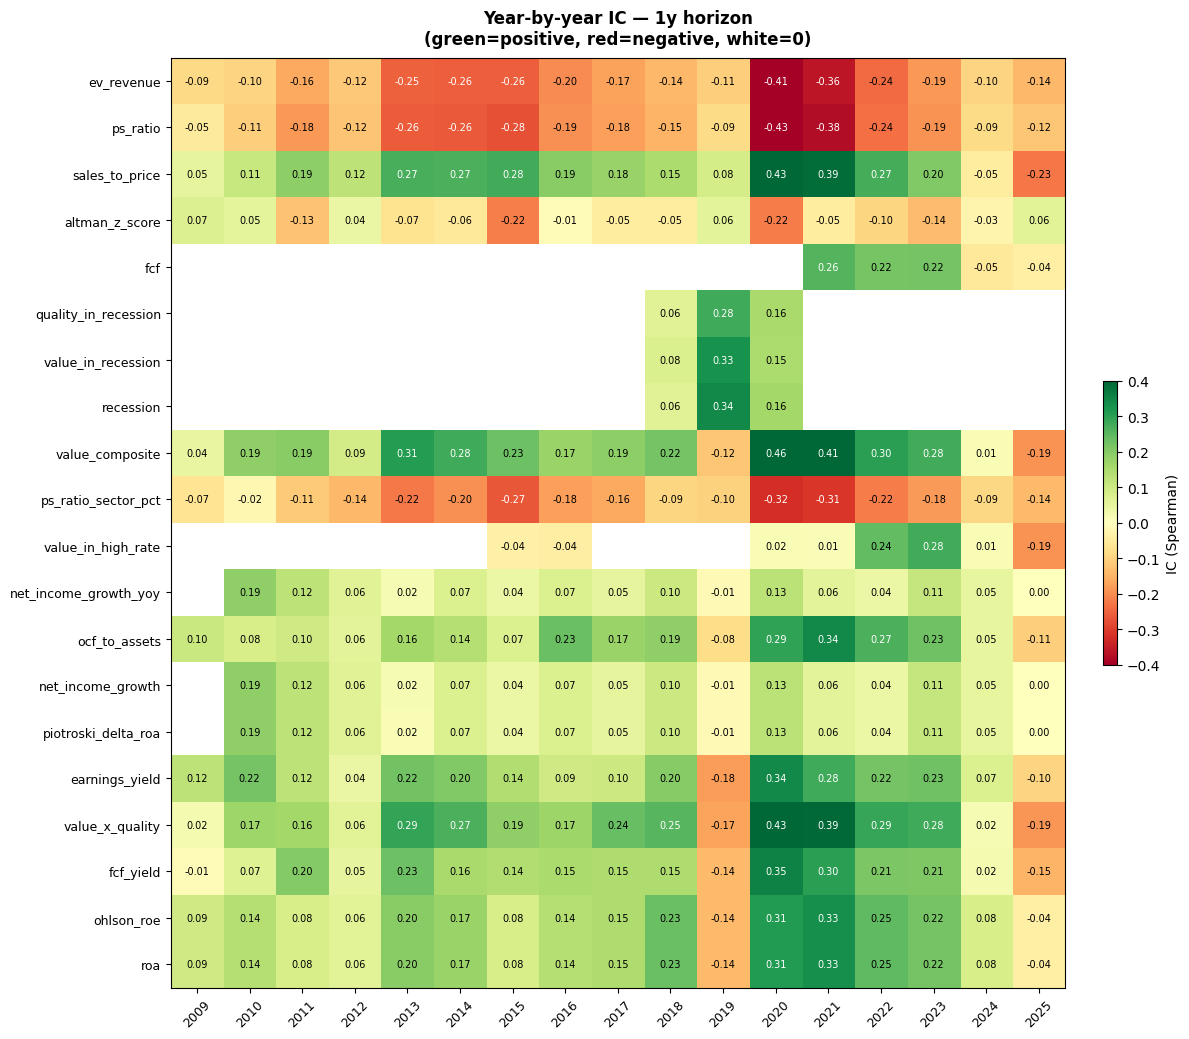


Temporal IC stability summary (1y horizon):
                       mean_IC  std_IC   ICIR  pct_same_sign  n_years
ev_revenue              -0.194   0.093 -2.090          1.000       17
ps_ratio_sector_pct     -0.167   0.084 -1.987          1.000       17
ps_ratio                -0.195   0.103 -1.893          1.000       17
quality_in_recession     0.166   0.109  1.524          1.000        3
value_in_recession       0.183   0.129  1.420          1.000        3
recession                0.189   0.141  1.343          1.000        3
net_income_growth        0.069   0.052  1.338          0.938       16
net_income_growth_yoy    0.069   0.052  1.338          0.938       16
piotroski_delta_roa      0.069   0.052  1.338          0.938       16
roa                      0.139   0.118  1.171          0.882       17
ohlson_roe               0.139   0.118  1.170          0.882       17
ocf_to_assets            0.135   0.122  1.110          0.882       17
sales_to_price           0.171   0.156  1.098

In [8]:
# Heatmap: feature × year IC
feat_cols = [f for f in top_feats if f in ic_by_year.columns]
heat_data = ic_by_year[feat_cols].T

fig, ax = plt.subplots(figsize=(max(12, len(ic_by_year) * 0.55), len(feat_cols) * 0.45 + 1.5))
im = ax.imshow(heat_data.values, aspect='auto', cmap='RdYlGn', vmin=-0.4, vmax=0.4)

ax.set_xticks(range(len(ic_by_year)))
ax.set_xticklabels(ic_by_year.index.astype(int), rotation=45, fontsize=9)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols, fontsize=9)

# Annotate cells
for i, f in enumerate(feat_cols):
    for j, yr in enumerate(ic_by_year.index):
        v = heat_data.loc[f, yr]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(v) < 0.25 else 'white')

plt.colorbar(im, ax=ax, fraction=0.015, pad=0.04, label='IC (Spearman)')
ax.set_title(f'Year-by-year IC — {FOCUS_HORIZON} horizon\n(green=positive, red=negative, white=0)', 
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'../reports/temporal_ic_stability_{FOCUS_HORIZON}.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table: mean IC, std IC, ICIR, fraction of years with consistent sign
ic_summary = pd.DataFrame({
    'mean_IC':  heat_data.mean(axis=1),
    'std_IC':   heat_data.std(axis=1),
    'ICIR':     heat_data.mean(axis=1) / heat_data.std(axis=1).replace(0, np.nan),
    'pct_same_sign': heat_data.apply(
        lambda row: ((row > 0).sum() / row.notna().sum()
                     if row.mean() > 0
                     else (row < 0).sum() / row.notna().sum()), axis=1),
    'n_years': heat_data.notna().sum(axis=1),
}).sort_values('ICIR', key=abs, ascending=False)

print(f'\nTemporal IC stability summary ({FOCUS_HORIZON} horizon):')
print(ic_summary.round(3).to_string())
print(f'\nSaved → reports/temporal_ic_stability_{FOCUS_HORIZON}.png')


## 7 — IC Decay Curves

Measures mean IC at t+1y, t+2y, and t+3y for the top selected features. Factors with persistent IC across horizons are structural (value, quality). Factors whose IC decays to near-zero by t+2y are short-lived signals (momentum reversals, short-term earnings surprises).

Note: t+2y uses the 3-year return; t+3y uses the 5-year return — these are the closest available proxies for multi-year hold periods in this dataset.

IC decay: mean IC at each horizon for top features
                           1y      2y      3y
feature                                      
ev_revenue            -0.1944 -0.3095 -0.3474
ps_ratio_sector_pct   -0.1667 -0.2433 -0.2817
ocf_growth_yoy         0.0495  0.0540  0.0340
capex_intensity       -0.0109 -0.0515 -0.0906
value_composite        0.1805  0.2862  0.3388
pb_ratio_sector_pct   -0.0622 -0.0754 -0.0940
ocf_to_assets          0.1349  0.1913  0.2147
net_income_growth_yoy  0.0689  0.0726  0.0734
altman_x5              0.0463  0.1078  0.1043
altman_x4             -0.1250 -0.2170 -0.2261


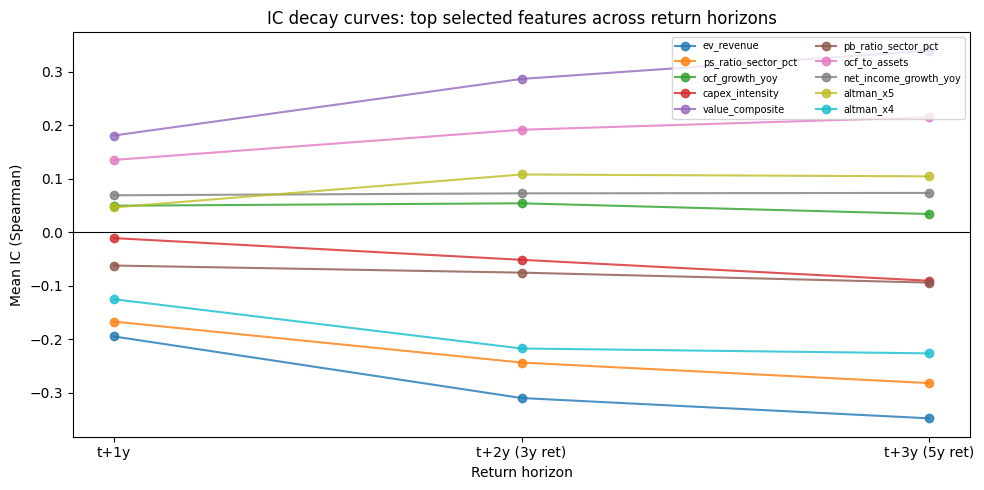

In [9]:

# IC decay curves: measure IC at t+1y, t+2y, t+3y for top features
# If IC decays quickly → short-lived signal (momentum); slowly → structural factor
# Persistent IC at t+2y and t+3y is the hallmark of a "true" value/quality factor

raw_decay = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_decay = raw_decay[raw_decay['period_type'] == 'annual'].copy()

import json
from scipy import stats as scipy_stats

TOP_DECAY = 10
try:
    feats_1y = json.load(open(ROOT / 'models' / 'feature_sets_1y.json'))['features'][:TOP_DECAY]
    feats_1y = [f for f in feats_1y if f in raw_decay.columns]
except Exception:
    feats_1y = []

RET_COLS = {'1y': 'forward_return_1y', '2y': 'forward_return_3y', '3y': 'forward_return_5y'}

decay_records = []
for feat in feats_1y:
    row = {'feature': feat}
    for lag_label, ret_col in RET_COLS.items():
        if ret_col not in raw_decay.columns:
            row[lag_label] = np.nan
            continue
        ic_years = raw_decay[raw_decay[ret_col].notna()].groupby('fiscal_year').apply(
            lambda g, f=feat, r=ret_col: g[[f, r]].dropna()[f].corr(
                g[[f, r]].dropna()[r], method='spearman'
            ) if len(g[[f, r]].dropna()) > 10 else float('nan')
        ).dropna()
        row[lag_label] = ic_years.mean() if len(ic_years) >= 3 else np.nan
    decay_records.append(row)

if decay_records:
    decay_df = pd.DataFrame(decay_records).set_index('feature')
    print('IC decay: mean IC at each horizon for top features')
    print(decay_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    x = [1, 2, 3]
    for feat in decay_df.index:
        ic_vals = [decay_df.loc[feat, '1y'], decay_df.loc[feat, '2y'], decay_df.loc[feat, '3y']]
        if all(pd.isna(v) for v in ic_vals):
            continue
        ax.plot(x, ic_vals, marker='o', linewidth=1.5, label=feat[:25], alpha=0.8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['t+1y', 't+2y (3y ret)', 't+3y (5y ret)'])
    ax.set_xlabel('Return horizon')
    ax.set_ylabel('Mean IC (Spearman)')
    ax.set_title('IC decay curves: top selected features across return horizons')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    plt.tight_layout()
    plt.show()


## 8 — Quintile Return Spreads (Q1 vs Q5)

Rank stocks into 5 quintiles by factor value within each fiscal year. If the factor has genuine predictive power, Q5 (highest factor value) should earn higher forward returns than Q1 (lowest). Sharpe ratio per quintile = mean_return / cross_sectional_std.

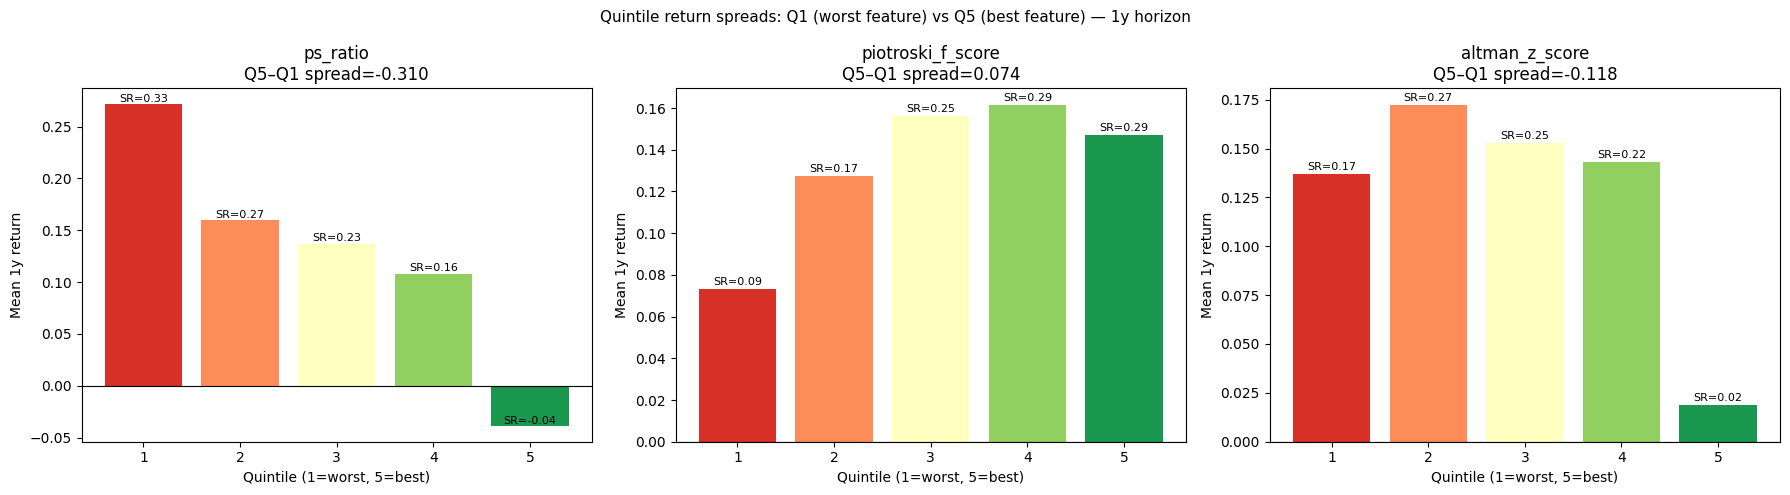

In [10]:

# Quintile return spreads: Q1–Q5 annualized returns + Sharpe ratio
# If IC is predictive, Q5 (top quintile) should outperform Q1 (bottom)
# Sharpe uses cross-sectional std of returns within quintile as proxy for volatility

raw_q = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_q = raw_q[(raw_q['period_type'] == 'annual') & raw_q['forward_return_1y'].notna()].copy()

FEATS_Q = ['ps_ratio', 'piotroski_f_score', 'altman_z_score']  # illustrative top features
FEATS_Q = [f for f in FEATS_Q if f in raw_q.columns]
RET_Q = 'forward_return_1y'

fig, axes = plt.subplots(1, len(FEATS_Q), figsize=(6 * len(FEATS_Q), 5))
if len(FEATS_Q) == 1:
    axes = [axes]

for ax, feat in zip(axes, FEATS_Q):
    raw_q['_q'] = raw_q.groupby('fiscal_year')[feat].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1
        if x.notna().sum() >= 25 else np.nan
    )
    q_stats = raw_q.groupby('_q')[RET_Q].agg(['mean', 'std', 'count'])
    sharpe = q_stats['mean'] / q_stats['std'] * np.sqrt(1)  # annualized (1y return)
    ax.bar(q_stats.index, q_stats['mean'], color=['#d73027','#fc8d59','#ffffbf','#91cf60','#1a9850'])
    ax.set_title(f'{feat}\nQ5–Q1 spread={q_stats["mean"].iloc[-1]-q_stats["mean"].iloc[0]:.3f}')
    ax.set_xlabel('Quintile (1=worst, 5=best)')
    ax.set_ylabel('Mean 1y return')
    ax.axhline(0, color='black', linewidth=0.8)
    for i, (idx, row) in enumerate(q_stats.iterrows()):
        ax.text(idx, row['mean'] + 0.002, f'SR={sharpe[idx]:.2f}', ha='center', fontsize=8)
    raw_q.drop(columns=['_q'], inplace=True)

plt.suptitle('Quintile return spreads: Q1 (worst feature) vs Q5 (best feature) — 1y horizon', fontsize=11)
plt.tight_layout()
plt.show()


## 9 — Fama-MacBeth Cross-Sectional Regression

For each fiscal year, run OLS of rank(forward_return) on rank(feature). Collect annual slopes, then compute t-stat = mean(slope) / (std(slope) / sqrt(T)). t > 1.96 indicates the factor premium is statistically significant at 5%.

Reference: Fama, E.F. & MacBeth, J.D. (1973). "Risk, Return, and Equilibrium: Empirical Tests." *Journal of Political Economy*, 81(3), 607–636.

Fama-MacBeth cross-sectional regression results:
                    feature horizon  mean_slope  std_slope  t_stat  n_years
                   ps_ratio      3y      -0.317      0.089 -13.814       15
           value_x_momentum      3y       0.238      0.078  11.860       15
  debt_to_assets_sector_pct      3y       0.081      0.027  11.459       15
                  altman_x4      3y      -0.217      0.077 -10.992       15
        ps_ratio_sector_pct      3y      -0.243      0.096  -9.796       15
              price_to_book      3y      -0.110      0.044  -9.752       15
            value_composite      3y       0.286      0.115   9.672       15
              vol_prior_36m      3y      -0.270      0.110  -9.477       15
                 ev_revenue      1y      -0.194      0.093  -8.619       17
        ps_ratio_sector_pct      1y      -0.167      0.084  -8.200       17
quarterly_positive_rev_frac      3y       0.312      0.199   6.067       15
        pb_ratio_sector_pct      1y    

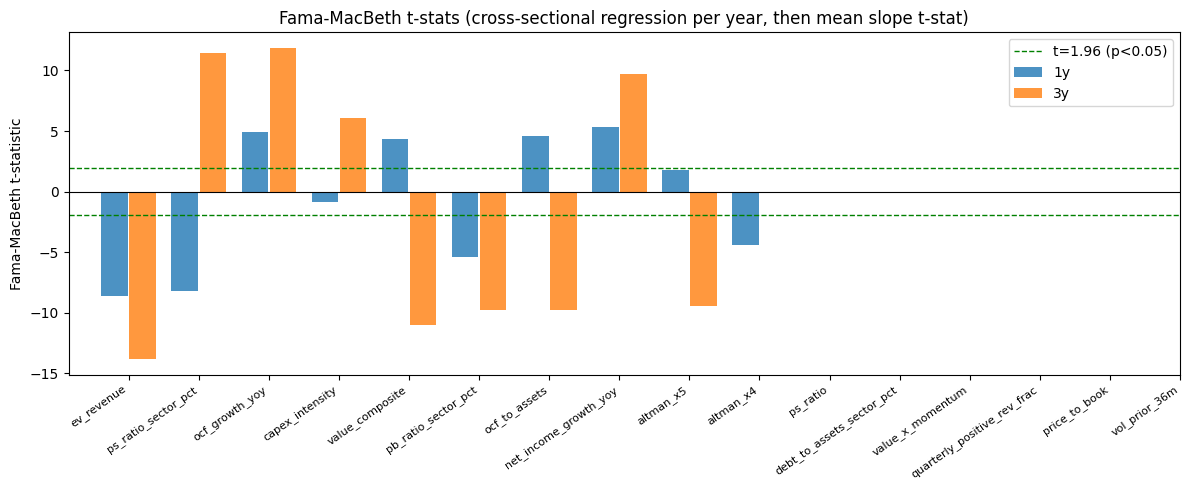

In [11]:

# Fama-MacBeth cross-sectional regression
# Each year: regress forward_return on factor values (OLS) → get slope_t
# Then t-stat on time series of slopes (mean / std / sqrt(T)) tests whether
# factor has positive expected return in cross-section
# Reference: Fama & MacBeth (1973) Journal of Political Economy

from scipy import stats as scipy_stats
import json

raw_fm = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_fm = raw_fm[(raw_fm['period_type'] == 'annual')].copy()

HORIZONS_FM = {'1y': 'forward_return_1y', '3y': 'forward_return_3y'}
TOP_FM = 10

fm_results = []
for h, ret_col in HORIZONS_FM.items():
    if ret_col not in raw_fm.columns:
        continue
    try:
        feats_fm = json.load(open(ROOT / 'models' / f'feature_sets_{h}.json'))['features'][:TOP_FM]
        feats_fm = [f for f in feats_fm if f in raw_fm.columns]
    except Exception:
        continue
    subset = raw_fm[raw_fm[ret_col].notna()].copy()
    for feat in feats_fm:
        slopes = []
        for yr in sorted(subset['fiscal_year'].dropna().unique()):
            g = subset[subset['fiscal_year'] == yr][[feat, ret_col]].dropna()
            if len(g) < 20:
                continue
            # Rank-normalize feature (Spearman-equivalent cross-sectional ranking)
            x = g[feat].rank(pct=True)
            y = g[ret_col].rank(pct=True)
            slope, intercept, r, p, se = scipy_stats.linregress(x, y)
            slopes.append(slope)
        if len(slopes) < 3:
            continue
        s = pd.Series(slopes)
        fm_t = s.mean() / (s.std() / np.sqrt(len(s)))
        fm_results.append({'feature': feat, 'horizon': h, 'mean_slope': s.mean(),
                          'std_slope': s.std(), 't_stat': fm_t, 'n_years': len(slopes)})

if fm_results:
    fm_df = pd.DataFrame(fm_results)
    print('Fama-MacBeth cross-sectional regression results:')
    print(fm_df.sort_values('t_stat', key=abs, ascending=False).round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 5))
    for h in HORIZONS_FM:
        sub = fm_df[fm_df['horizon'] == h].set_index('feature')['t_stat']
        x = np.arange(len(sub))
        ax.bar(x + (0.2 if h == '3y' else -0.2), sub.values, 0.38, label=f'{h}', alpha=0.8)
    ax.axhline(1.96, color='green', linestyle='--', linewidth=1, label='t=1.96 (p<0.05)')
    ax.axhline(-1.96, color='green', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(np.arange(len(fm_df['feature'].unique())))
    ax.set_xticklabels(fm_df['feature'].unique(), rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Fama-MacBeth t-statistic')
    ax.set_title('Fama-MacBeth t-stats (cross-sectional regression per year, then mean slope t-stat)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 10 — Market Regime IC (Recession vs Expansion)

Tests whether factor IC is stable across NBER recession vs expansion periods. A factor that only works in recessions is a distress proxy, not a general alpha factor. Uses the `recession` column (1 = NBER recession, 0 = expansion).

Regime IC for ps_ratio (forward_return_1y):
  Recession  years: n=2  mean_IC=-0.309  std=0.100
  Expansion  years: n=17  mean_IC=-0.191  std=0.108


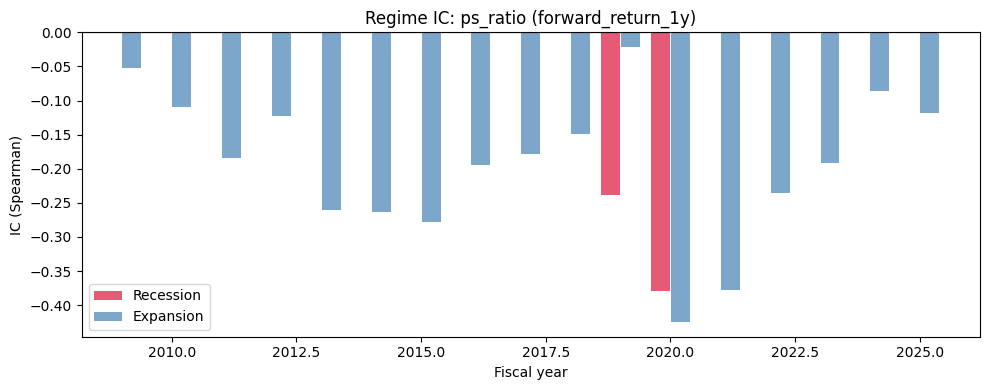

In [12]:

# Market regime IC: recession vs expansion split
# If IC only works in recessions it's a distress factor, not an alpha factor
raw_reg = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_reg = raw_reg[(raw_reg['period_type'] == 'annual') & raw_reg['forward_return_1y'].notna()].copy()

FEAT_REG = 'ps_ratio'  # change to explore other features
RET_REG = 'forward_return_1y'

if 'recession' in raw_reg.columns and FEAT_REG in raw_reg.columns:
    rec_rows = raw_reg[raw_reg['recession'] == 1]
    exp_rows = raw_reg[raw_reg['recession'] == 0]

    def yearly_ic(df, feat, ret):
        return df.groupby('fiscal_year').apply(
            lambda g: g[[feat, ret]].dropna()[feat].corr(
                g[[feat, ret]].dropna()[ret], method='spearman'
            ) if len(g[[feat, ret]].dropna()) > 10 else float('nan')
        ).dropna()

    ic_rec = yearly_ic(rec_rows, FEAT_REG, RET_REG)
    ic_exp = yearly_ic(exp_rows, FEAT_REG, RET_REG)

    print(f'Regime IC for {FEAT_REG} ({RET_REG}):')
    print(f'  Recession  years: n={len(ic_rec)}  mean_IC={ic_rec.mean():.3f}  std={ic_rec.std():.3f}')
    print(f'  Expansion  years: n={len(ic_exp)}  mean_IC={ic_exp.mean():.3f}  std={ic_exp.std():.3f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    years_all = sorted(set(ic_rec.index) | set(ic_exp.index))
    ax.bar([y - 0.2 for y in ic_rec.index], ic_rec.values, 0.38, label='Recession', color='crimson', alpha=0.7)
    ax.bar([y + 0.2 for y in ic_exp.index], ic_exp.values, 0.38, label='Expansion', color='steelblue', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Regime IC: {FEAT_REG} ({RET_REG})')
    ax.set_xlabel('Fiscal year')
    ax.set_ylabel('IC (Spearman)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"'recession' column missing or {FEAT_REG} not in dataset — regime split skipped")
    print('To add: merge NBER recession indicator via macro enrichment step')


## 11 — Long-Short Return Decomposition

Decomposes factor premium into long leg (Q5) vs short leg (Q1). A factor where the premium comes entirely from the short leg is harder to implement (short selling constraints). L-S spread = Q5 mean return − Q1 mean return.

Long-short decomposition (1y horizon, unconditional):
                       long_ret  short_ret  ls_spread  long_sharpe  short_sharpe
feature                                                                         
ev_revenue              -0.0429     0.2772    -0.3200      -0.0408        0.2756
ps_ratio_sector_pct     -0.0436     0.2555    -0.2991      -0.0429        0.2538
ocf_growth_yoy           0.1786     0.1357     0.0429       0.2010        0.1279
capex_intensity          0.1075     0.1181    -0.0106       0.1161        0.1252
value_composite          0.2012     0.1180     0.0832       0.2934        0.0950
pb_ratio_sector_pct     -0.0129     0.1585    -0.1714      -0.0148        0.1386
ocf_to_assets            0.1583     0.0844     0.0739       0.2246        0.0678
net_income_growth_yoy    0.1742     0.1338     0.0404       0.2082        0.1292


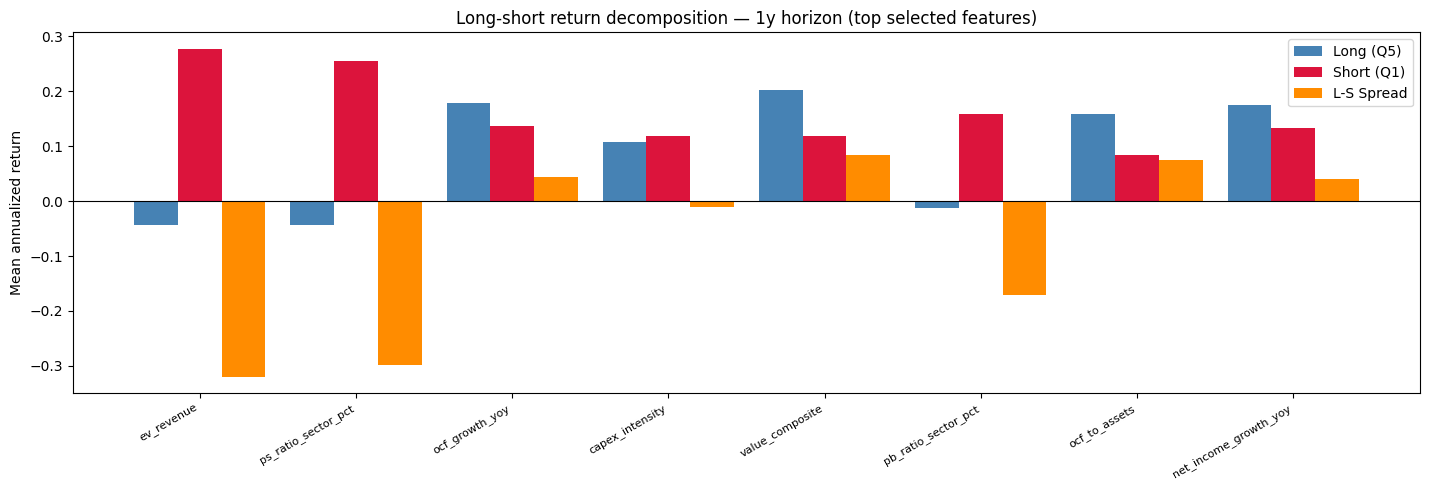

In [13]:

# Long-short return decomposition: long Q5 (top quintile) vs short Q1 (bottom quintile)
# Tests whether positive IC comes from long leg, short leg, or both (Asness et al.)
raw_ls = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_ls = raw_ls[(raw_ls['period_type'] == 'annual') & raw_ls['forward_return_1y'].notna()].copy()

import json
try:
    FEATS_LS = json.load(open(ROOT / 'models' / 'feature_sets_1y.json'))['features'][:8]
    FEATS_LS = [f for f in FEATS_LS if f in raw_ls.columns]
except Exception:
    FEATS_LS = []

ret_col_ls = 'forward_return_1y'
results_ls = []
for feat in FEATS_LS:
    q_col = feat + '_q'
    raw_ls[q_col] = raw_ls.groupby('fiscal_year')[feat].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1 if x.notna().sum() >= 20 else np.nan
    )
    q_stats = raw_ls.groupby(q_col)[ret_col_ls].agg(['mean', 'std', 'count'])
    if q_stats.notna().all().all() and len(q_stats) >= 5:
        long_ret = q_stats.loc[5, 'mean']  # Q5 = top quintile by feature
        short_ret = q_stats.loc[1, 'mean']  # Q1 = bottom quintile
        ls_ret = long_ret - short_ret
        long_sharpe = long_ret / q_stats.loc[5, 'std'] * np.sqrt(252/365) if q_stats.loc[5, 'std'] > 0 else np.nan
        short_sharpe = short_ret / q_stats.loc[1, 'std'] * np.sqrt(252/365) if q_stats.loc[1, 'std'] > 0 else np.nan
        results_ls.append({'feature': feat, 'long_ret': long_ret, 'short_ret': short_ret,
                          'ls_spread': ls_ret, 'long_sharpe': long_sharpe, 'short_sharpe': short_sharpe})
    raw_ls.drop(columns=[q_col], inplace=True)

if results_ls:
    ls_df = pd.DataFrame(results_ls).set_index('feature')
    print('Long-short decomposition (1y horizon, unconditional):')
    print(ls_df.round(4).to_string())

    x = np.arange(len(ls_df))
    w = 0.28
    fig, ax = plt.subplots(figsize=(max(10, len(ls_df) * 1.8), 5))
    ax.bar(x - w, ls_df['long_ret'], width=w, label='Long (Q5)', color='steelblue')
    ax.bar(x, ls_df['short_ret'], width=w, label='Short (Q1)', color='crimson')
    ax.bar(x + w, ls_df['ls_spread'], width=w, label='L-S Spread', color='darkorange')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(ls_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Mean annualized return')
    ax.set_title('Long-short return decomposition — 1y horizon (top selected features)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 12 — Information Ratio per Factor

IR = mean(IC) / std(IC) — measures consistency of the signal. IR > 0.5 is the Grinold & Kahn institutional quality threshold. A factor with high mean IC but low IR (high IC volatility) is unreliable across regimes.

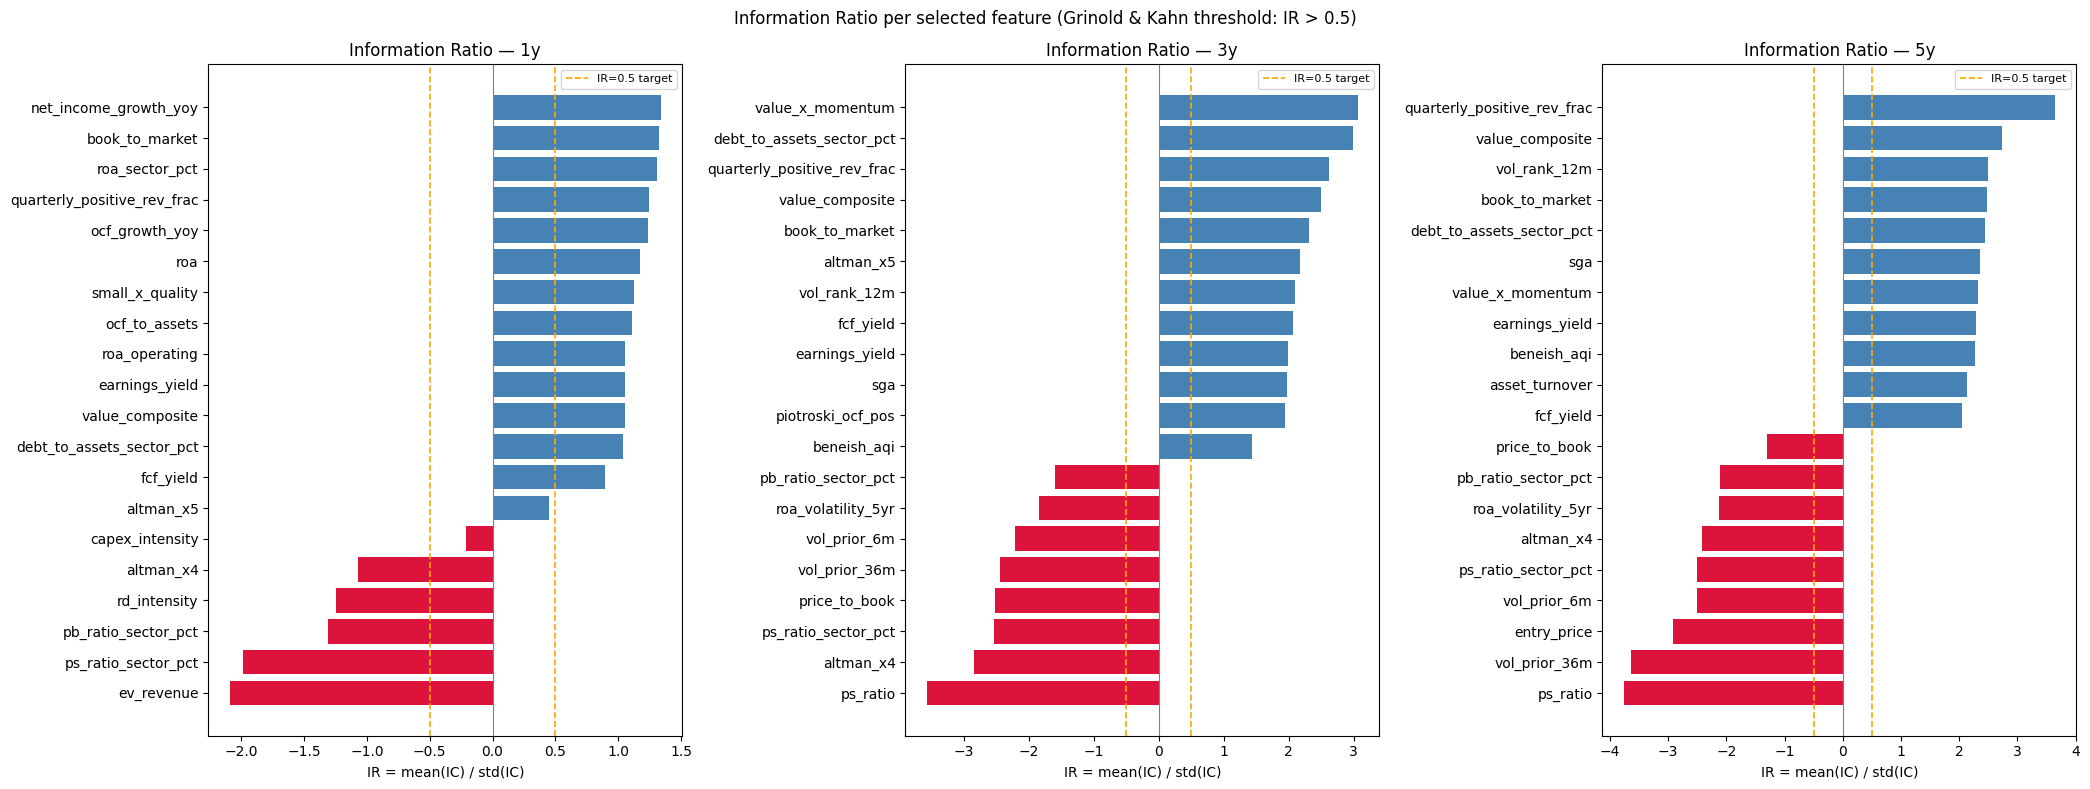

In [14]:

# Information Ratio = mean(IC) / std(IC) across years — per selected feature
# IR > 0.5 is considered "good" in quant finance (Grinold & Kahn 2000)
import json

HORIZONS_IR = {'1y': 'forward_return_1y', '3y': 'forward_return_3y', '5y': 'forward_return_5y'}
TOP_N_IR = 20
raw_ir = pd.read_parquet(ROOT / 'data' / 'historical_dataset_clean.parquet')
raw_ir = raw_ir[raw_ir['period_type'] == 'annual'].copy()

fig, axes = plt.subplots(1, len(HORIZONS_IR), figsize=(7 * len(HORIZONS_IR), 8))

for ax, (h, ret_col) in zip(axes, HORIZONS_IR.items()):
    if ret_col not in raw_ir.columns:
        ax.set_title(f'IR {h} (no return data)'); continue
    try:
        feat_set = json.load(open(ROOT / 'models' / f'feature_sets_{h}.json'))['features']
    except Exception:
        ax.set_title(f'IR {h} (no feature set)'); continue
    feat_set = [f for f in feat_set if f in raw_ir.columns][:TOP_N_IR]
    subset = raw_ir[raw_ir[ret_col].notna()].copy()
    ir_dict = {}
    for feat in feat_set:
        ic_s = subset.groupby('fiscal_year').apply(
            lambda g, f=feat: g[[f, ret_col]].dropna()[f].corr(
                g[[f, ret_col]].dropna()[ret_col], method='spearman'
            ) if len(g[[f, ret_col]].dropna()) > 5 else float('nan')
        ).dropna()
        if len(ic_s) < 3: continue
        ir_dict[feat] = ic_s.mean() / ic_s.std()
    ir_s = pd.Series(ir_dict).sort_values()
    colors = ['steelblue' if v >= 0 else 'crimson' for v in ir_s.values]
    ax.barh(ir_s.index, ir_s.values, color=colors)
    ax.axvline(0.5, color='orange', linestyle='--', linewidth=1.2, label='IR=0.5 target')
    ax.axvline(-0.5, color='orange', linestyle='--', linewidth=1.2)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(f'Information Ratio — {h}')
    ax.set_xlabel('IR = mean(IC) / std(IC)')
    ax.legend(fontsize=8)

plt.suptitle('Information Ratio per selected feature (Grinold & Kahn threshold: IR > 0.5)', fontsize=12)
plt.tight_layout()
plt.show()
